# LightGBMによる楽曲人気度予測

このNotebookでは、LightGBMの基本的な使い方を確認しながら、使用する特徴量を4段階で増やして予測性能を比較する。

## 分析の流れ

1. データを読み込む  
2. 数値特徴量とカテゴリ特徴量を準備する  
3. 学習用データと検証用データに分割する  
4. 4種類の特徴量構成でLightGBMを学習する  
5. MSEとRMSEを比較する  
6. 特徴量重要度を確認する  
7. 最も良い特徴量構成でテストデータを予測する  

## 4つの実験

| 実験 | 使用する特徴量 |
|---|---|
| 1 | 数値特徴量のみ |
| 2 | 数値特徴量 + ジャンル |
| 3 | 数値特徴量 + アーティスト |
| 4 | 数値特徴量 + ジャンル + アーティスト |


## 1. ライブラリの読み込み

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

pd.set_option("display.max_columns", None)

print("LightGBM version:", lgb.__version__)


LightGBM version: 4.6.0


## 2. Google Driveをマウントしてデータを読み込む

`NOTEBOOK_DIR`は、このNotebookを保存しているフォルダに合わせて変更する。


In [2]:
# 1. Google Driveをマウント
drive.mount("/content/drive")

# 2. Notebookが置かれているGoogle Drive上のフォルダを指定
NOTEBOOK_DIR = (
    "/content/drive/My Drive/Colab Notebooks/情報理工実験/データサイエンス/Lecture02"
)

# 3. カレントディレクトリを変更
os.chdir(NOTEBOOK_DIR)
print("現在の作業フォルダ:", os.getcwd())

# 4. データを読み込む
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
submission_example = pd.read_csv("data/y_pred_example.csv")

print("データの読み込みが完了しました。")
print("train:", train.shape)
print("test :", test.shape)


Mounted at /content/drive
現在の作業フォルダ: /content/drive/My Drive/Colab Notebooks/情報理工実験/データサイエンス/Lecture02
データの読み込みが完了しました。
train: (79800, 21)
test : (34200, 20)


## 3. 使用する特徴量を定義する

数値特徴量は、先の特徴量分析で確認したものを中心に使用する。

`key`、`mode`、`time_signature`は、今回は分析を簡素にするため除外する。


In [3]:
target = "popularity"

numeric_features = [
    "duration_ms",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

experiments = {
    "1. Numeric only": numeric_features,
    "2. Numeric + Genre": numeric_features + ["track_genre"],
    "3. Numeric + Artist": numeric_features + ["artists"],
    "4. Numeric + Genre + Artist": numeric_features + ["track_genre", "artists"]
}

for name, features in experiments.items():
    print(name, ":", features)


1. Numeric only : ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
2. Numeric + Genre : ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'track_genre']
3. Numeric + Artist : ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'artists']
4. Numeric + Genre + Artist : ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'track_genre', 'artists']


## 4. カテゴリ特徴量を準備する

LightGBMでは、文字列カテゴリを`category`型に変換して直接使用できる。

訓練データとテストデータでカテゴリの定義を揃えるため、両方の値から共通のカテゴリ型を作る。


In [4]:
categorical_features = ["track_genre", "artists"]

for col in categorical_features:
    all_values = pd.concat([train[col], test[col]], axis=0)
    category_type = pd.CategoricalDtype(categories=all_values.dropna().unique())

    train[col] = train[col].astype(category_type)
    test[col] = test[col].astype(category_type)

print("カテゴリ特徴量の準備が完了しました。")


カテゴリ特徴量の準備が完了しました。


## 5. 学習用データと検証用データに分割する

4つの実験を公平に比較するため、すべて同じ分割を使用する。


In [5]:
train_index, valid_index = train_test_split(
    train.index,
    test_size=0.2,
    random_state=42
)

y_train = train.loc[train_index, target]
y_valid = train.loc[valid_index, target]

print("学習データ数:", len(train_index))
print("検証データ数:", len(valid_index))


学習データ数: 63840
検証データ数: 15960


## 6. LightGBMを学習する関数

この関数では、次の処理を行う。

1. 指定した特徴量を取り出す  
2. LightGBM回帰モデルを作る  
3. `fit()`で学習する  
4. `predict()`で検証データを予測する  
5. MSEとRMSEを計算する  


In [6]:
def train_lightgbm(features):
    # 使用する特徴量だけを取り出す
    X_train = train.loc[train_index, features]
    X_valid = train.loc[valid_index, features]

    # LightGBM回帰モデルを作成
    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )

    # 検証データを使って、学習の進み具合を確認しながら学習
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="mse",
        categorical_feature=[
            col for col in features if col in categorical_features
        ],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0)
        ]
    )

    # 検証データを予測
    y_pred = model.predict(
        X_valid,
        num_iteration=model.best_iteration_
    )

    # 評価指標を計算
    mse = mean_squared_error(y_valid, y_pred)
    rmse = np.sqrt(mse)

    return model, mse, rmse


## 7. 4つの実験を実行する

特徴量構成だけを変更し、LightGBMの設定はすべて同じにする。


In [7]:
results = []
models = {}

for experiment_name, features in experiments.items():
    model, mse, rmse = train_lightgbm(features)

    models[experiment_name] = model

    results.append({
        "experiment": experiment_name,
        "number_of_features": len(features),
        "MSE": mse,
        "RMSE": rmse,
        "best_iteration": model.best_iteration_
    })

    print(
        f"{experiment_name}: "
        f"MSE={mse:.4f}, RMSE={rmse:.4f}"
    )

results_df = pd.DataFrame(results).sort_values("MSE")
display(results_df)


1. Numeric only: MSE=385.5179, RMSE=19.6346
2. Numeric + Genre: MSE=301.4116, RMSE=17.3612
3. Numeric + Artist: MSE=316.8954, RMSE=17.8016
4. Numeric + Genre + Artist: MSE=258.6887, RMSE=16.0838


,experiment,number_of_features,MSE,RMSE,best_iteration
3,4. Numeric + Genre + Artist,12,258.688650,16.083801,500
1,2. Numeric + Genre,11,301.411598,17.361210,500
2,3. Numeric + Artist,11,316.895393,17.801556,500
0,1. Numeric only,10,385.517922,19.634610,500


## 8. 実験結果をグラフで比較する

MSEが小さいほど、予測誤差が小さい。


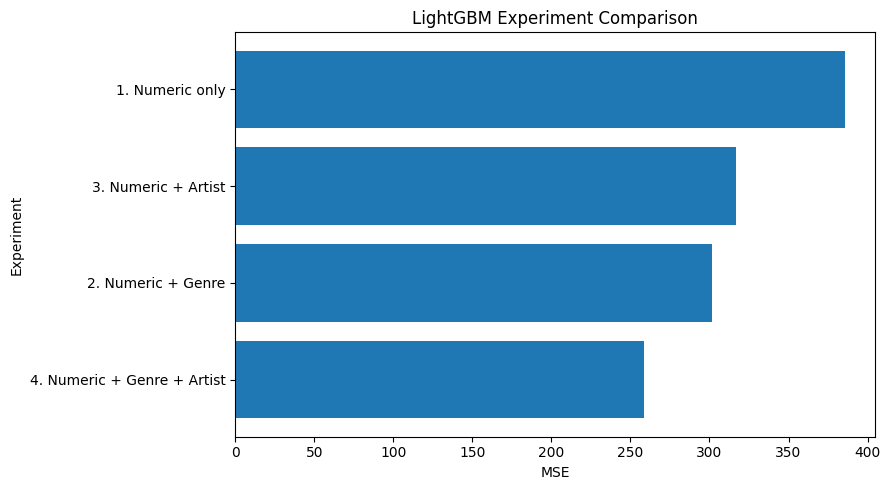

In [8]:
plot_df = results_df.sort_values("MSE", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["experiment"], plot_df["MSE"])
plt.xlabel("MSE")
plt.ylabel("Experiment")
plt.title("LightGBM Experiment Comparison")
plt.tight_layout()
plt.show()


## 9. 最も良いモデルの特徴量重要度を確認する

LightGBMが予測に多く使用した特徴量を確認する。

ここでの重要度は、特徴量が木の分岐に使用された回数を表す。


In [9]:
best_experiment = results_df.iloc[0]["experiment"]
best_model = models[best_experiment]
best_features = experiments[best_experiment]

importance_df = pd.DataFrame({
    "feature": best_features,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Best experiment:", best_experiment)
display(importance_df)


Best experiment: 4. Numeric + Genre + Artist


,feature,importance
11,artists,2470
10,track_genre,2364
4,speechiness,1198
3,loudness,1135
7,liveness,1084
0,duration_ms,1071
1,danceability,1047
5,acousticness,1024
9,tempo,981
8,valence,977


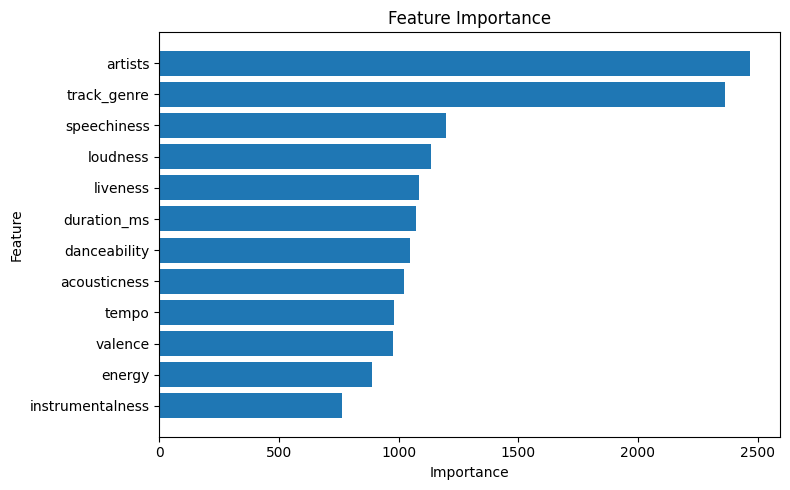

In [10]:
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


## 10. 最も良い特徴量構成で全訓練データを学習する

検証で最も良かった特徴量構成を使い、訓練データ全体でモデルを作り直す。


In [11]:
X_full = train[best_features]
y_full = train[target]
X_test = test[best_features]

# 検証時に選ばれた学習回数を使用
best_n_estimators = int(
    results_df.iloc[0]["best_iteration"]
)

final_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

final_model.fit(
    X_full,
    y_full,
    categorical_feature=[
        col for col in best_features if col in categorical_features
    ]
)

test_pred = final_model.predict(X_test)
test_pred = np.clip(test_pred, 0, 100)  # 0~100に限定

print("最終モデルの学習と予測が完了しました。")
print("使用した実験:", best_experiment)


最終モデルの学習と予測が完了しました。
使用した実験: 4. Numeric + Genre + Artist


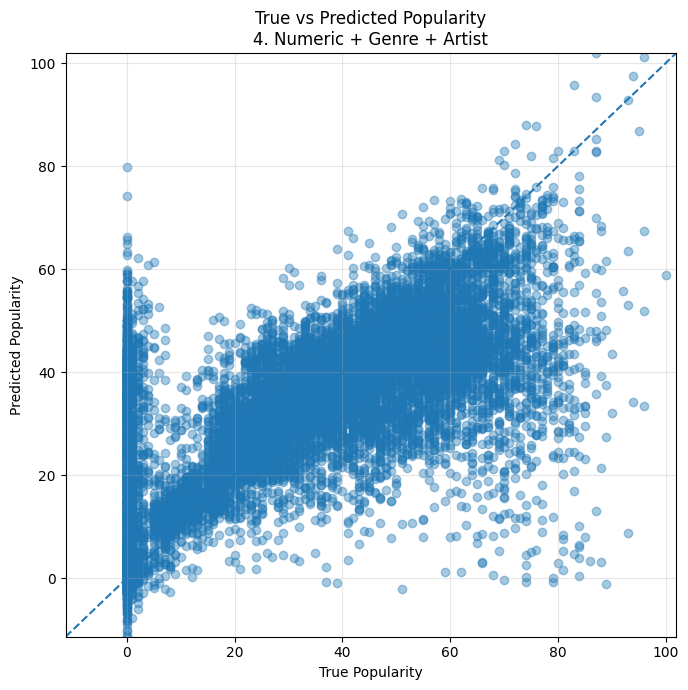

In [12]:
# 最良モデルが使用する検証データを準備
X_valid_best = train.loc[valid_index, best_features]

# 検証データのpopularityを予測
y_valid_pred = best_model.predict(
    X_valid_best,
    num_iteration=best_model.best_iteration_
)

# 真値と予測値の散布図
plt.figure(figsize=(7, 7))
plt.scatter(y_valid, y_valid_pred, alpha=0.4)

# 真値と予測値が完全に一致する基準線
min_value = min(y_valid.min(), y_valid_pred.min())
max_value = max(y_valid.max(), y_valid_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("True Popularity")
plt.ylabel("Predicted Popularity")
plt.title(f"True vs Predicted Popularity\n{best_experiment}")

plt.xlim(min_value, max_value)
plt.ylim(min_value, max_value)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. 提出用CSVを作成する

`y_pred_example.csv`の形式を保ったまま、予測値を保存する。


In [13]:
# test.csvに対する予測値だけを、1列で保存する
pd.Series(test_pred).to_csv(
    "submission/lightgbm_submission.csv",
    index=False,
    header=False
)

print("保存先: lightgbm_submission.csv")


保存先: lightgbm_submission.csv


## 12. まとめ

このNotebookでは、LightGBMの基本的な操作を確認した。

- `LGBMRegressor()`でモデルを作成した
- `fit()`で学習した
- `predict()`で予測した
- MSEとRMSEで性能を比較した
- カテゴリ特徴量を`category`型として使用した
- 特徴量重要度を確認した
- テストデータの予測結果をCSVに保存した

4つの実験結果を比較することで、ジャンルとアーティストを追加した効果を確認できる。
